In [23]:
print("Hello Faisal")

Hello Faisal


In [58]:
import pandas as pd
import numpy as np

print("Pandas Loaded Successfully")

Pandas Loaded Successfully


In [59]:
df_patn = pd.read_excel(r"C:\Users\ABC\Desktop\HEALTHCARE\panda\STG_EHP__PATN.xlsx",sheet_name="STG_EHP__PATN")

In [60]:
df_patn.shape

(351765, 23)

In [61]:
excel_file = pd.ExcelFile(r"C:\Users\ABC\Desktop\HEALTHCARE\panda\STG_EHP__PATN.xlsx")

print(excel_file.sheet_names)

['Sheet1', 'Sheet2', 'STG_EHP__PATN']


In [62]:
df_patn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351765 entries, 0 to 351764
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   PAT_ID        351765 non-null  object 
 1   F_NAME        351765 non-null  object 
 2   L_NAME        351765 non-null  object 
 3   M_NAME        175694 non-null  object 
 4   GEN_CD        351765 non-null  int64  
 5   GEN_DES       351765 non-null  object 
 6   DT_BRT        351765 non-null  object 
 7   AGE           0 non-null       float64
 8   CON_NO        351765 non-null  object 
 9   EM_ADD        351765 non-null  object 
 10  EC_F_NAME     351765 non-null  object 
 11  EC_L_NAME     351765 non-null  object 
 12  EC_M_NAME     177118 non-null  object 
 13  EC_CON_NO     351765 non-null  object 
 14  B_TYPE        351765 non-null  object 
 15  MAR_ST        351765 non-null  object 
 16  NAT_ID_S      351765 non-null  object 
 17  NAT_ID_T      351765 non-null  object 
 18  NAT_

In [63]:
df_patn.columns

Index(['PAT_ID', 'F_NAME', 'L_NAME', 'M_NAME', 'GEN_CD', 'GEN_DES', 'DT_BRT',
       'AGE', 'CON_NO', 'EM_ADD', 'EC_F_NAME', 'EC_L_NAME', 'EC_M_NAME',
       'EC_CON_NO', 'B_TYPE', 'MAR_ST', 'NAT_ID_S', 'NAT_ID_T', 'NAT_ID_N',
       'NAT_ID_E', 'INGST_TMSTMP', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

In [28]:
df_patn[['Unnamed: 21','Unnamed: 22']].head()

,Unnamed: 21,Unnamed: 22
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [64]:
df_patn.columns =(df_patn.columns.str.strip().str.lower())

In [30]:
df_patn.columns

Index(['pat_id', 'f_name', 'l_name', 'm_name', 'gen_cd', 'gen_des', 'dt_brt',
       'age', 'con_no', 'em_add', 'ec_f_name', 'ec_l_name', 'ec_m_name',
       'ec_con_no', 'b_type', 'mar_st', 'nat_id_s', 'nat_id_t', 'nat_id_n',
       'nat_id_e', 'ingst_tmstmp', 'unnamed: 21', 'unnamed: 22'],
      dtype='object')

In [65]:
df_patn = df_patn.drop(
    columns=['unnamed: 21', 'unnamed: 22']
)

In [66]:
df_patn.shape

(351765, 21)

In [67]:
df_patn.isnull().sum()

pat_id               0
f_name               0
l_name               0
m_name          176071
gen_cd               0
gen_des              0
dt_brt               0
age             351765
con_no               0
em_add               0
ec_f_name            0
ec_l_name            0
ec_m_name       174647
ec_con_no            0
b_type               0
mar_st               0
nat_id_s             0
nat_id_t             0
nat_id_n             0
nat_id_e             0
ingst_tmstmp         0
dtype: int64

In [69]:
df_patn['gen_des'].value_counts()

gen_des
Female    117905
Male      117254
Other     116606
Name: count, dtype: int64

In [70]:
df_patn['b_type'].value_counts()

b_type
B-     44476
AB-    44141
AB+    44055
B+     44048
O-     43965
A-     43964
A+     43756
O+     43360
Name: count, dtype: int64

In [71]:
df_patn['mar_st'].value_counts()

mar_st
Unmarried    176053
Married      175712
Name: count, dtype: int64

In [72]:
df_patn['nat_id_t'].value_counts()

nat_id_t
Passport      117931
License       116966
Green Card    116868
Name: count, dtype: int64

In [73]:
df_patn['pat_id'].nunique()

351765

In [74]:
df_patn['pat_id'].duplicated().sum()

np.int64(0)

In [75]:
df_patn['dt_brt']=pd.to_datetime(
    df_patn['dt_brt'],
    errors='coerce'
)

In [76]:
#To calculate age = today - DOB
from datetime import datetime

today = pd.Timestamp.today()

df_patn['age'] = (
    (today - df_patn['dt_brt']).dt.days // 365
)

In [77]:
df_patn['age'].describe()

count    351765.000000
mean         40.193061
std          22.514692
min           1.000000
25%          21.000000
50%          40.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

In [78]:
df_patn['age'].head(10)

0    26
1    19
2    45
3    25
4    13
5    25
6     4
7    13
8    31
9    71
Name: age, dtype: int64

In [79]:
df_patn['age'].value_counts().sort_index()

age
1     1407
2     4392
3     4571
4     4491
5     4691
      ... 
76    4194
77    4383
78    4519
79    3365
80     203
Name: count, Length: 80, dtype: int64

In [80]:
df_patn['age'].min()


1

In [81]:
df_patn['age'].max()

80

In [82]:
df_patn['age_group']=pd.cut(
    df_patn['age'] ,
    bins=[0,18,30,45,60,120],
    labels=[
        'Child',
        'Young Adult',
        'Adult',
        'Middle Age',
        'Senior'
    ])

In [83]:
df_patn['age_group'].value_counts()

age_group
Senior         84114
Child          77788
Adult          67690
Middle Age     67589
Young Adult    54584
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

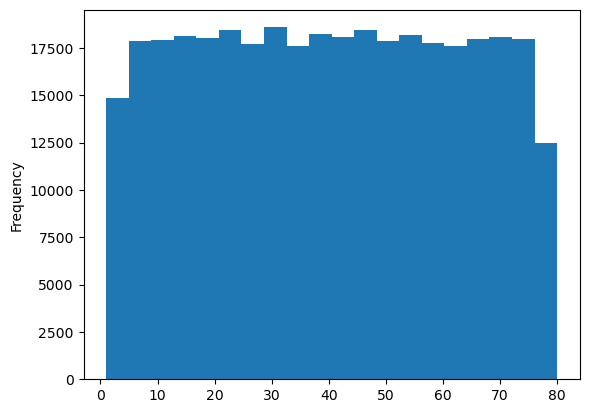

In [84]:
df_patn['age'].plot(kind='hist', bins=20)

In [85]:
excel_file = pd.ExcelFile(
    r"C:\Users\ABC\Desktop\HEALTHCARE\panda\STG_EHP__VIST.xlsx"
)

print(excel_file.sheet_names)

['Sheet1', 'Sheet2', 'STG_EHP__VIST']


In [86]:
df_vist = pd.read_excel(
    r"C:\Users\ABC\Desktop\HEALTHCARE\panda\STG_EHP__VIST.xlsx",
    sheet_name="STG_EHP__VIST"
)

In [89]:
path = r"C:\Users\ABC\Desktop\HEALTHCARE\panda\STG_EHP__VIST.xlsx"

print(path)

C:\Users\ABC\Desktop\HEALTHCARE\panda\STG_EHP__VIST.xlsx


In [90]:
df_vist.shape

(917331, 10)

In [91]:
df_vist.columns

Index(['REFR_NO', 'PAT_ID', 'MEDT_ID', 'VIS_EN', 'VIS_EX', 'VSTAT_CD',
       'VSTAT_DES', 'VTYPE_CD', 'VTYPE_DES', 'ROM_ID'],
      dtype='object')

In [92]:
df_vist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917331 entries, 0 to 917330
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   REFR_NO    917331 non-null  object        
 1   PAT_ID     917331 non-null  object        
 2   MEDT_ID    917331 non-null  object        
 3   VIS_EN     917331 non-null  datetime64[ns]
 4   VIS_EX     917331 non-null  datetime64[ns]
 5   VSTAT_CD   917331 non-null  int64         
 6   VSTAT_DES  917331 non-null  object        
 7   VTYPE_CD   917331 non-null  int64         
 8   VTYPE_DES  917331 non-null  object        
 9   ROM_ID     667086 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 70.0+ MB


In [93]:
df_vist.describe()

,VIS_EN,VIS_EX,VSTAT_CD,VTYPE_CD
count,917331,917331,917331.000000,917331.000000
mean,2024-11-14 02:00:48.843960320,2025-02-22 22:56:48.254036992,1.000430,0.500348
min,2024-01-01 06:00:38,2024-01-01 19:58:24,0.000000,0.000000
25%,2024-06-08 06:36:47,2024-09-17 04:27:24.500000,0.000000,0.000000
50%,2024-11-14 11:07:59,2025-02-23 08:35:35,1.000000,1.000000
75%,2025-04-21 17:37:20,2025-07-31 17:15:07.500000,2.000000,1.000000
max,2025-09-27 17:59:33,2026-04-17 03:50:44,2.000000,1.000000
std,NaN,NaN,0.916755,0.500000


In [94]:
df_vist.columns=(df_vist.columns.str.strip().str.lower())
df_vist.columns

Index(['refr_no', 'pat_id', 'medt_id', 'vis_en', 'vis_ex', 'vstat_cd',
       'vstat_des', 'vtype_cd', 'vtype_des', 'rom_id'],
      dtype='object')

In [96]:
len(df_vist)

917331

In [ ]:
#Average Visits Per Patient = Total visit / no of patients

avg_vist= len(df_vist)/df_vist['pat_id'].nunique()
avg_vist


2.8153409875611124

In [97]:
df_vist["vstat_des"].value_counts()

vstat_des
Need Follow-Up    385677
Discharged        385283
Admitted          146371
Name: count, dtype: int64

In [98]:
#Find out whether there are any duplicate visit reference numbers.

df_vist["refr_no"].duplicated().sum()

np.int64(12350)

In [99]:
df_vist["refr_no"].drop_duplicates()

0         W4723062
1         W1448670
2         W9016417
3         W2919500
4         E8063843
            ...   
917325    W4648159
917326     1849560
917328    E1554450
917329    E6431027
917330     2557548
Name: refr_no, Length: 904981, dtype: object

In [100]:
df_vist["refr_no"].nunique()

904981

In [101]:
#Which patient has visited the hospital the most number of times?

df_vist.groupby("pat_id")["refr_no"].count().sort_values(ascending=False)

pat_id
9920410N    13
191467X     13
9095656Z    12
7706911V    12
5929454X    12
            ..
4182924K     1
8075776S     1
4183077A     1
8075694C     1
5496519G     1
Name: refr_no, Length: 325833, dtype: int64

In [102]:
#What is the average duration of a hospital visit?

df_vist["visit_duration"] =df_vist["vis_ex"] - df_vist["vis_en"]
df_vist["visit_duration"]

0         85 days 21:27:55
1         60 days 15:32:53
2        121 days 08:49:20
3         34 days 13:15:25
4        153 days 04:47:20
                ...       
917326    99 days 08:54:02
917327    26 days 16:02:51
917328    48 days 05:11:44
917329    96 days 06:32:45
917330    51 days 17:51:34
Name: visit_duration, Length: 917331, dtype: timedelta64[ns]

In [103]:
#What is the average visit duration across all visits?

df_vist["visit_duration"].mean()

Timedelta('100 days 20:55:59.410075538')

In [104]:
#Which visit type is the most common in the hospital?

df_vist["vtype_des"].value_counts()

vtype_des
Treatment    458985
Diagnosis    458346
Name: count, dtype: int64

In [105]:
#Which visit status is the most common?

df_vist["vstat_des"].value_counts()

vstat_des
Need Follow-Up    385677
Discharged        385283
Admitted          146371
Name: count, dtype: int64

In [106]:
#Show me the actual duplicate visit reference numbers and how many times each one occurs.

df_vist.groupby("refr_no").size().loc[lambda x:x>1]

refr_no
E1111774    2
E1111884    2
E1113537    2
E1113724    2
E1114050    2
           ..
W9992937    2
W9993560    2
W9995047    2
W9996243    2
W9998222    2
Length: 12207, dtype: int64

In [107]:
#Which patient has the highest number of visits?

df_vist.groupby("pat_id")["refr_no"].count().sort_values(ascending=False).head()

pat_id
9920410N    13
191467X     13
9095656Z    12
7706911V    12
5929454X    12
Name: refr_no, dtype: int64

In [108]:
#How many patients visited only once?

visit_count = df_vist.groupby("pat_id")["refr_no"].count()

(visit_count == 1).sum()

np.int64(67564)

In [109]:
#Which doctor (medt_id) handled the highest number of visits?

df_vist.groupby("medt_id")["pat_id"].nunique().sort_values(ascending=False).head(1)

medt_id
853D655    48
Name: pat_id, dtype: int64

In [110]:
#Which patient visited the largest number of different doctors?

df_vist.groupby("pat_id")["medt_id"].nunique().sort_values(ascending=False).head(1)

pat_id
191467X    13
Name: medt_id, dtype: int64

In [111]:
#Month with most visits

In [112]:
#Room with most visits

df_vist.groupby("rom_id")["refr_no"].count().sort_values(ascending=False)

rom_id
C12165P    94
A36531R    92
T23964M    92
B47367R    91
S15444C    91
           ..
X43123L    40
F42746E    39
L47626Y    39
A18872F    39
W78239J    36
Name: refr_no, Length: 10251, dtype: int64

In [113]:
df_vist[["vis_en", "vis_ex"]].head()

,vis_en,vis_ex
0,2025-09-27 17:59:33,2025-12-22 15:27:28
1,2025-09-27 17:57:48,2025-11-27 09:30:41
2,2025-09-27 17:56:46,2026-01-27 02:46:06
3,2025-09-27 17:56:13,2025-11-01 07:11:38
4,2025-09-27 17:56:00,2026-02-27 22:43:20


In [114]:
df_vist["vis_en"] = pd.to_datetime(df_vist["vis_en"])

df_vist.groupby(df_vist["vis_en"].dt.month)["refr_no"] \
       .nunique() \
       .sort_values(ascending=False)

vis_en
5     89502
8     89449
1     89312
3     89065
7     88862
6     86766
4     86593
2     82459
9     81707
12    44944
10    44645
11    42947
Name: refr_no, dtype: int64

In [115]:
df_vist["vis_en"].min(), df_vist["vis_en"].max()

(Timestamp('2024-01-01 06:00:38'), Timestamp('2025-09-27 17:59:33'))

In [116]:
import pandas as pd

df_diag1=pd.read_excel(
    r"C:\Users\ABC\Desktop\HEALTHCARE\dataset_new\STG_EHP__DIAG_1.xlsx",
    sheet_name="STG_EHP__DIAG_1"
)

df_diag2=pd.read_excel(
    r"C:\Users\ABC\Desktop\HEALTHCARE\dataset_new\STG_EHP__DIAG_2.xlsx",
    sheet_name="STG_EHP__DIAG_2"
)

KeyboardInterrupt: 

In [ ]:
import os

os.listdir(r"C:\Users\ABC\Desktop\HEALTHCARE\panda")

['Healthcare_Operations_Analytics.ipynb',
 'STG_EHP__PATN.xlsx',
 'STG_EHP__VIST.xlsx']

In [ ]:
df_diag1.columns , df_diag2.columns



(Index(['REFR_NO', 'DIG_TOT', 'DIG_EN', 'DIG_SEQ', 'DIG_CD', 'DIG_DES',
        'DSTAT_CD', 'DSTAT_DES', 'DTYPE_CD', 'DTYPE_DES', 'ROM_ID'],
       dtype='object'),
 Index(['REFR_NO', 'DIG_TOT', 'DIG_EN', 'DIG_SEQ', 'DIG_CD', 'DIG_DES',
        'DSTAT_CD', 'DSTAT_DES', 'DTYPE_CD', 'DTYPE_DES', 'ROM_ID'],
       dtype='object'))

In [117]:
df_diag1.columns = df_diag1.columns.str.strip().str.lower()
df_diag2.columns = df_diag2.columns.str.strip().str.lower()

df_diag1.columns ,df_diag2.columns 

(Index(['refr_no', 'dig_tot', 'dig_en', 'dig_seq', 'dig_cd', 'dig_des',
        'dstat_cd', 'dstat_des', 'dtype_cd', 'dtype_des', 'rom_id'],
       dtype='object'),
 Index(['refr_no', 'dig_tot', 'dig_en', 'dig_seq', 'dig_cd', 'dig_des',
        'dstat_cd', 'dstat_des', 'dtype_cd', 'dtype_des', 'rom_id'],
       dtype='object'))

In [118]:
#How many unique diagnosis codes are present in DIAG_1?

df_unique = df_diag1["dig_cd"].nunique()

df_unique 

40

In [119]:
#Which diagnosis code appears most frequently in DIAG_1?

df_diag1["dig_cd"].value_counts().head(1)

dig_cd
36    24085
Name: count, dtype: int64

In [120]:
#Which diagnosis description (dig_des) appears most frequently in DIAG_1?

df_diag1["dig_des"].value_counts().head(1)

dig_des
Occupational Health    24085
Name: count, dtype: int64

In [121]:
#Which diagnosis description (dig_des) is associated with the highest number of unique visits (refr_no)?

df_diag1.groupby("dig_des")["refr_no"].nunique().sort_values(ascending=False).head(1)

dig_des
Occupational Health    23102
Name: refr_no, dtype: int64

In [122]:
#Which room (rom_id) has the highest number of diagnosis records in DIAG_1?

df_diag1.groupby("rom_id")["refr_no"].count().sort_values(ascending=False).head(1)

rom_id
J91861R    461
Name: refr_no, dtype: int64

In [123]:
#Which diagnosis code (dig_cd) is recorded in the highest number of unique rooms (rom_id)?

df_diag1.groupby("dig_cd")["rom_id"].nunique().sort_values(ascending=False).head(1)

dig_cd
25    3884
Name: rom_id, dtype: int64

In [128]:
# Which diagnosis code (dig_cd) is associated with the highest number of unique patients?

# First merge then find common

diag_merge = pd.merge( df_diag1,df_vist , on="refr_no" ,how="inner")
diag_merge.head(5)

diag_merge.groupby("dig_cd")["pat_id"].nunique().sort_values(ascending=False).head(1)

dig_cd
36    22987
Name: pat_id, dtype: int64

In [129]:
#Which diagnosis description (dig_des) is associated with the highest number of unique patients?

diag_merge.groupby("dig_des")["pat_id"].nunique().sort_values(ascending=False).head(1)


dig_des
Occupational Health    22987
Name: pat_id, dtype: int64

In [133]:
#Are there any visits (refr_no) that have more than one diagnosis recorded?

df_diag1.groupby("refr_no")["dig_cd"].count().loc[lambda x:x>1]

refr_no
1000322     6
1000901     5
1001104     2
1001414     3
1001491     3
           ..
W9999365    5
W9999447    2
W9999487    5
W9999492    5
W9999616    4
Name: dig_cd, Length: 225624, dtype: int64

In [135]:
#What is the maximum number of diagnoses assigned to a single visit?

df_diag1.groupby("refr_no")["dig_cd"].count().max()

14

In [136]:
#What percentage of visits have more than 1 diagnosis?

diag_count_per_visit = df_diag1.groupby("refr_no")["dig_cd"].count()

percentage = (
    (diag_count_per_visit > 1).sum()
    / diag_count_per_visit.shape[0]
) * 100


In [137]:
# Description mapped to multiple diagnosis codes

df_diag1.groupby("dig_des")["dig_cd"].nunique().loc[lambda x: x > 1]

Series([], Name: dig_cd, dtype: int64)

In [ ]:
#Diagnosis description with highest unique patients

diag_merge.groupby("dig_des")["pat_id"] \
          .nunique() \
          .sort_values(ascending=False) \
          .head(1)

dig_des
Occupational Health    22987
Name: pat_id, dtype: int64

In [140]:
df_treatment = pd.read_excel(
    r"C:\Users\ABC\Desktop\HEALTHCARE\dataset_new\STG_EHP__TRTM.xlsx",
    sheet_name="STG_EHP__TRTM"
)

In [141]:
# Shape

df_treatment.shape

(917191, 10)

In [142]:
# First few rows

df_treatment.head()

,REFR_NO,TRTM_TOT,TRTM_EN,TTYPE_CD,TTYPE_DES,TRTM_CD,TSTAT_CD,TRTM_DES,TSTAT_DES,TRTM_SEQ
0,W2919500,1,2025-09-27 17:56:13,7,Complementary,0,4,Cardiovascular,Declined,1
1,E8063843,3,2025-09-27 17:56:00,7,Complementary,1,0,Respiratory,Planned,1
2,E8063843,3,2025-09-27 17:56:00,4,Prophylactic,21,5,Reproductive (Female),Not Tolerated,2
3,E8063843,3,2025-09-27 17:56:00,6,Supportive,17,0,Hearing,Planned,3
4,W6301404,2,2025-09-27 17:54:28,5,Critical,13,2,Gastroenterology,Completed,1


In [143]:
# Data types
df_treatment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917191 entries, 0 to 917190
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   REFR_NO    917191 non-null  object        
 1   TRTM_TOT   917191 non-null  int64         
 2   TRTM_EN    917191 non-null  datetime64[ns]
 3   TTYPE_CD   917191 non-null  int64         
 4   TTYPE_DES  917191 non-null  object        
 5   TRTM_CD    917191 non-null  int64         
 6   TSTAT_CD   917191 non-null  int64         
 7   TRTM_DES   917191 non-null  object        
 8   TSTAT_DES  917191 non-null  object        
 9   TRTM_SEQ   917191 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 70.0+ MB


In [144]:
# Columns

df_treatment.columns

Index(['REFR_NO', 'TRTM_TOT', 'TRTM_EN', 'TTYPE_CD', 'TTYPE_DES', 'TRTM_CD',
       'TSTAT_CD', 'TRTM_DES', 'TSTAT_DES', 'TRTM_SEQ'],
      dtype='object')

In [145]:
df_treatment.columns = df_treatment.columns.str.strip().str.lower()


In [146]:
# Verify
df_treatment.columns

Index(['refr_no', 'trtm_tot', 'trtm_en', 'ttype_cd', 'ttype_des', 'trtm_cd',
       'tstat_cd', 'trtm_des', 'tstat_des', 'trtm_seq'],
      dtype='object')

In [148]:
# Missing values
df_treatment.isnull().sum()

refr_no      0
trtm_tot     0
trtm_en      0
ttype_cd     0
ttype_des    0
trtm_cd      0
tstat_cd     0
trtm_des     0
tstat_des    0
trtm_seq     0
dtype: int64

In [149]:
# Duplicate rows
df_treatment.duplicated().sum()

np.int64(0)

In [150]:
# Total treatment records
len(df_treatment)

917191

In [151]:
# Unique treatment codes
df_treatment["trtm_cd"].nunique()


29

In [152]:
# Top 10 treatment codes
df_treatment["trtm_cd"].value_counts().head(10)


trtm_cd
4     31893
11    31884
27    31847
10    31812
28    31776
13    31766
1     31766
8     31764
0     31763
2     31759
Name: count, dtype: int64

In [153]:
# Treatment type distribution

df_treatment["ttype_des"].value_counts()

ttype_des
Prophylactic       92013
Rehabilitation     91986
Pharmacological    91855
Psychological      91851
Critical           91774
Surgical           91689
Supportive         91671
Complementary      91607
Nutritional        91567
Transplantation    91178
Name: count, dtype: int64

In [154]:
# Visit with maximum treatments

df_treatment.groupby("refr_no")["trtm_cd"] \
            .count() \
            .sort_values(ascending=False) \
            .head(1)

refr_no
W6099413    7
Name: trtm_cd, dtype: int64

In [155]:
# Distribution of treatments per visit

df_treatment.groupby("refr_no")["trtm_cd"] \
            .count() \
            .value_counts()

trtm_cd
2    151515
1    151125
3    151113
4      1052
5       681
6       345
7         2
Name: count, dtype: int64

In [156]:
# Monthly treatment trend

df_treatment["trtm_en"] = pd.to_datetime(df_treatment["trtm_en"])

df_treatment.groupby(
    df_treatment["trtm_en"].dt.month
)["refr_no"].count()

trtm_en
1     89218
2     82600
3     89451
4     86364
5     89144
6     87285
7     88520
8     89697
9     81348
10    44648
11    43403
12    45513
Name: refr_no, dtype: int64

In [157]:
# Busiest month by treatment volume

df_treatment.groupby(
    df_treatment["trtm_en"].dt.month
)["refr_no"].count().sort_values(ascending=False).head(1)

trtm_en
8    89697
Name: refr_no, dtype: int64

In [158]:
# Missing values analysis

df_treatment.isnull().sum()

refr_no      0
trtm_tot     0
trtm_en      0
ttype_cd     0
ttype_des    0
trtm_cd      0
tstat_cd     0
trtm_des     0
tstat_des    0
trtm_seq     0
dtype: int64

In [159]:
# Merge treatment and visit

trtm_visit = pd.merge(
    df_treatment,
    df_vist,
    on="refr_no",
    how="inner"
)

In [160]:
# Treatment performed on highest number of unique patients

trtm_visit.groupby("trtm_des")["pat_id"] \
          .nunique() \
          .sort_values(ascending=False) \
          .head(1)

trtm_des
Hepatic    30600
Name: pat_id, dtype: int64

In [161]:
# Room with highest treatment volume

trtm_visit.groupby("rom_id")["trtm_cd"] \
          .count() \
          .sort_values(ascending=False) \
          .head(1)

rom_id
S52573X    119
Name: trtm_cd, dtype: int64

In [162]:
# Visit type with highest treatment volume

trtm_visit.groupby("vtype_des")["trtm_cd"] \
          .count() \
          .sort_values(ascending=False)

vtype_des
Treatment    929769
Diagnosis     12422
Name: trtm_cd, dtype: int64

In [163]:
import pandas as pd

df_billing = pd.read_excel(
    r"C:\Users\ABC\Desktop\HEALTHCARE\dataset_new\STG_EHP__BILL.xlsx",
    sheet_name="STG_EHP__BILL"
)

In [165]:
df_billing.columns = df_billing.columns.str.strip().str.lower()
df_billing.columns

Index(['refr_no', 'pat_id', 'bill_date', 'bill_amt', 'bstat_cd', 'bstat_des',
       'btype_cd', 'unnamed: 7', 'unnamed: 8', 'unnamed: 9', 'unnamed: 10',
       'unnamed: 11', 'unnamed: 12', 'unnamed: 13', 'unnamed: 14'],
      dtype='object')

In [166]:
# Total billing records
len(df_billing)



917331

In [167]:
# Total revenue generated
df_billing["bill_amt"].sum()

np.int64(9034137000)

In [168]:
# Billing amount statistics
df_billing["bill_amt"].describe()

count    917331.000000
mean       9848.284861
std        8055.732602
min        1000.000000
25%        5000.000000
50%        9000.000000
75%       11000.000000
max      139000.000000
Name: bill_amt, dtype: float64

In [169]:
# Average bill amount
df_billing["bill_amt"].mean()


np.float64(9848.28486118969)

In [170]:
# Billing status distribution

df_billing["bstat_des"].value_counts()

bstat_des
Insurance Covered 80%       153448
Insurance Denied            153392
Write-Off                   153376
Insurance Covered 50%       153214
Insurance Covered 100%      153130
Pending Insurance Review    150771
Name: count, dtype: int64

In [171]:
# Most common billing status

df_billing["bstat_des"].value_counts().head(1)

bstat_des
Insurance Covered 80%    153448
Name: count, dtype: int64

In [172]:
# Top 10 highest bill amounts

df_billing.sort_values(
    by="bill_amt",
    ascending=False
).head(10)

,refr_no,pat_id,bill_date,bill_amt,bstat_cd,bstat_des,btype_cd,unnamed: 7,unnamed: 8,unnamed: 9,unnamed: 10,unnamed: 11,unnamed: 12,unnamed: 13,unnamed: 14
627391,W2438433,8676773H,2024-12-17 23:12:00,139000,0,Insurance Covered 100%,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
896992,W9465350,9051825M,2025-02-16 16:11:00,136000,6,Write-Off,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
746944,W5545619,8692693U,2026-02-09 15:13:00,136000,5,Pending Insurance Review,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
627390,W2438433,8010648Q,2024-12-14 14:12:00,130000,6,Write-Off,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
295614,E2344082,5723749O,2024-10-18 15:05:00,124000,2,Insurance Covered 50%,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889467,W9271712,450286Y,2025-11-03 17:13:00,124000,5,Pending Insurance Review,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889468,W9271712,578633J,2025-06-22 04:17:00,118000,6,Write-Off,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
896993,W9465350,4066290U,2024-04-06 21:59:00,112000,2,Insurance Covered 50%,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
295613,E2344082,7587130H,2024-10-18 21:38:00,112000,0,Insurance Covered 100%,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889470,W9271712,4732437I,2025-02-15 18:59:00,112000,1,Insurance Covered 80%,RG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Top 5 patients by total billing

df_billing.groupby("pat_id")["bill_amt"] \
          .sum() \
          .sort_values(ascending=False) \
          .head()

pat_id
8692693U    200000
1098672G    192000
3153341A    186000
5723749O    184000
9684605U    183000
Name: bill_amt, dtype: int64

In [174]:
# Top 10 visits by billing amount

df_billing.groupby("refr_no")["bill_amt"] \
          .sum() \
          .sort_values(ascending=False) \
          .head(10)

refr_no
W9271712    457000
W2438433    363000
E2344082    345000
W5545619    345000
W9465350    339000
E2678386    267000
W1546472    261000
W6457516    252000
W2980736    252000
E4952894    252000
Name: bill_amt, dtype: int64

In [175]:
# Average revenue per patient

df_billing.groupby("pat_id")["bill_amt"].sum().mean()

np.float64(27726.28002688494)

In [176]:
# Convert billing date

df_billing["bill_date"] = pd.to_datetime(
    df_billing["bill_date"]
)

In [178]:
# Month with highest revenue

df_billing.groupby(
    df_billing["bill_date"].dt.month
)["bill_amt"].sum().sort_values(ascending=False).head(1)

bill_date
8    880959000
Name: bill_amt, dtype: int64

In [179]:
# Month with highest billing volume

df_billing.groupby(
    df_billing["bill_date"].dt.month
)["refr_no"].count().sort_values(ascending=False).head(1)

bill_date
8    89383
Name: refr_no, dtype: int64

In [181]:
billing_visit = pd.merge(
    df_billing,
    df_vist,
    on=["refr_no","pat_id"],
    how="inner"
)

In [182]:
# Room generating highest revenue

billing_visit.groupby("rom_id")["bill_amt"].sum().sort_values(ascending=False).head(1)

rom_id
C12165P    1191000
Name: bill_amt, dtype: int64

In [183]:
# Revenue by visit type

billing_visit.groupby("vtype_des")["bill_amt"].sum().sort_values(ascending=False)

vtype_des
Diagnosis    6124943000
Treatment    2909194000
Name: bill_amt, dtype: int64